# MSPB - Non-invasive colony monitoring from hive acoustics

**Dataset:** MSPB (Multi-Sensor dataset with Phenotypic trait measurements from honey Bees, 53 hives, Québec, May 2020-Apr 2021). Each hive streams **20 audio features** every ~15 min; bee experts periodically record ground-truth **phenotype** measurements.

**Two questions a beekeeper actually cares about - answered from sound alone, without opening the hive:**

1. **Colony strength** - is this colony *large or small* (frames of bees)? Drives feeding/splitting decisions.
2. **Varroa load** - is mite infestation past the *3% economic treatment threshold*?

**How to read this notebook:** every step is *Question -> Plot -> Reasoning*. The headline result is not just a model - it's knowing **which task the data can and cannot support**, which is the real job.

## 0. Setup and the hive-ID join problem

Before any modelling there is a data-wrangling trap. The **sensor** table identifies hives by `tag_number` (e.g. `202040`), but the **phenotype** workbook uses `Hive ID` (e.g. `2040`). Joining them wrong silently destroys every label. The verified key: strip the leading `20` from `tag_number`. It maps **exactly 53/85 sensor tags onto the 53 known colonies** (the other 32 are non-hive devices), which is how we know the join is right and not coincidental.

In [1]:
import os, sys, warnings
warnings.filterwarnings('ignore')
sys.path.insert(0, os.path.join('..', 'src')); sys.path.insert(0, 'src')
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import mspb_loader as M
plt.rcParams.update({'figure.figsize': (11, 4.5), 'axes.grid': True, 'grid.alpha': .25})

# Load the 221 MB sensor table ONCE and reuse it for both tasks.
sensor = M.load_sensor('D1')
print('sensor rows:', f'{len(sensor):,}', '| hives:', sensor.hive_id.nunique(),
      '| audio features:', len(M.AUDIO_FEATURES))
print('date span:', sensor.ts.min().date(), '->', sensor.ts.max().date())

sensor rows: 960,809 | hives: 85 | audio features: 20
date span: 2020-04-16 -> 2020-11-05


## 1. What does the acoustic signal look like?

**Q:** Does a single hive's sound actually carry structured, time-varying information - or is it noise?

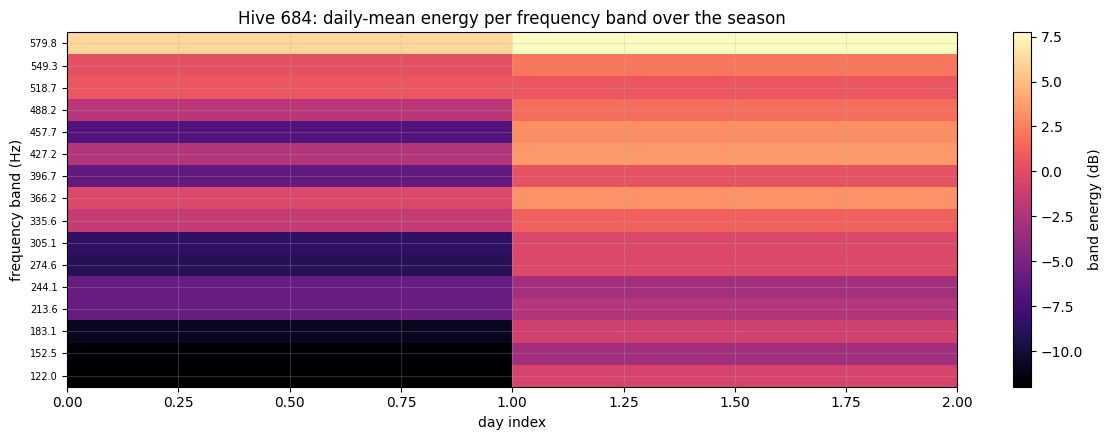

In [2]:
h = sensor.hive_id.value_counts().index[0]          # busiest hive
g = sensor[sensor.hive_id == h].set_index('ts').sort_index()
bands = [c for c in M.AUDIO_FEATURES if c.startswith('hz_')]
daily = g[bands].resample('1D').mean().dropna(how='all')
fig, ax = plt.subplots(figsize=(12, 4.5))
im = ax.imshow(daily.T.values, aspect='auto', cmap='magma',
               extent=[0, len(daily), 0, len(bands)])
ax.set_yticks(np.arange(len(bands)) + .5); ax.set_yticklabels([b.replace('hz_','')[:5] for b in bands], fontsize=7)
ax.set_xlabel('day index'); ax.set_ylabel('frequency band (Hz)')
ax.set_title(f'Hive {h}: daily-mean energy per frequency band over the season')
fig.colorbar(im, label='band energy (dB)'); plt.tight_layout(); plt.show()

**Reasoning:** the spectro-temporal pattern is clearly structured - low bands carry most energy and the profile drifts across the season as the colony grows and behaviour changes. That seasonal drift is exactly the signal the colony-strength model will exploit.

## 2. Labels and the feature/label join

Labels come from the phenotype workbook on inspection dates. For each `(hive, inspection date)` we take all sensor readings within **+/-3 days** and summarise the 20 features by **mean + 1st/2nd-order deltas** (60 features) - the same aggregation as the MSPB population baseline. Rows with **no** sensor coverage in the window are dropped, never imputed.

population samples: 291 | hives: 53 | features: 60
varroa samples    : 54 | hives: 53


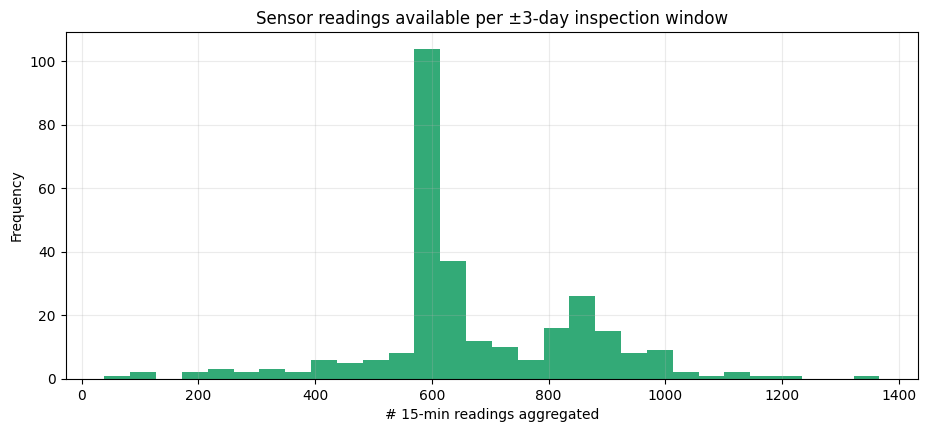

In [3]:
pop = M.build_population_dataset(sensor=sensor)
var = M.build_varroa_dataset(sensor=sensor)
feats = M.feature_columns(pop)
print('population samples:', len(pop), '| hives:', pop.hive_id.nunique(), '| features:', len(feats))
print('varroa samples    :', len(var), '| hives:', var.hive_id.nunique())
ax = pop.n_sensor_rows.plot.hist(bins=30, color='#3a7')
ax.set_title('Sensor readings available per +/-3-day inspection window')
ax.set_xlabel('# 15-min readings aggregated'); plt.show()

**Reasoning:** most inspection windows are backed by hundreds of readings, so the aggregated feature vectors are stable rather than single-snapshot noise. Good - the labels are well-grounded.

# Task A - Colony strength (population)

## A1. Is the label balanced?
**Q:** Large vs small at the FoB>20 split - is this a balanced problem where accuracy is meaningful?

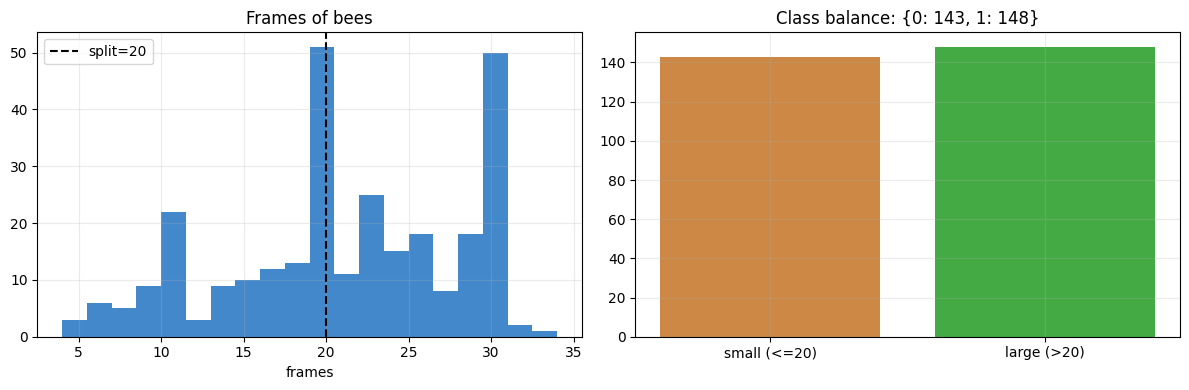

In [4]:
fob = pop.target_value
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].hist(fob, bins=20, color='#48c'); ax[0].axvline(M.FOB_SPLIT, color='k', ls='--', label='split=20')
ax[0].set_title('Frames of bees'); ax[0].set_xlabel('frames'); ax[0].legend()
vc = pop.label.value_counts().sort_index()
ax[1].bar(['small (<=20)','large (>20)'], vc.values, color=['#c84','#4a4'])
ax[1].set_title(f'Class balance: {vc.to_dict()}')
plt.tight_layout(); plt.show()

**Reasoning:** ~50/50. Balanced accuracy is a fair metric and a trivial majority-class guesser would score ~0.5, so anything well above 0.5 is real signal.

## A2. Do the acoustic features actually separate large vs small colonies?
**Q:** Before trusting any model, is there *visible* class separation in the features?

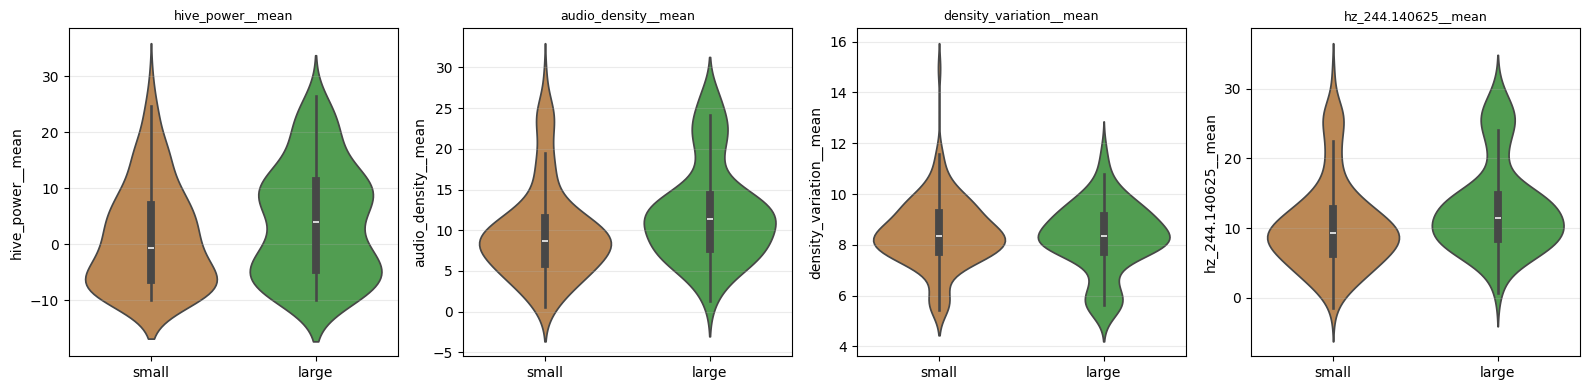

In [5]:
import seaborn as sns
show = [c for c in ['hive_power__mean','audio_density__mean','density_variation__mean','hz_244.140625__mean'] if c in feats]
fig, ax = plt.subplots(1, len(show), figsize=(4*len(show), 4))
for a, c in zip(np.atleast_1d(ax), show):
    sns.violinplot(data=pop, x='label', y=c, ax=a, palette=['#c84','#4a4'])
    a.set_xticklabels(['small','large']); a.set_xlabel(''); a.set_title(c, fontsize=9)
plt.tight_layout(); plt.show()

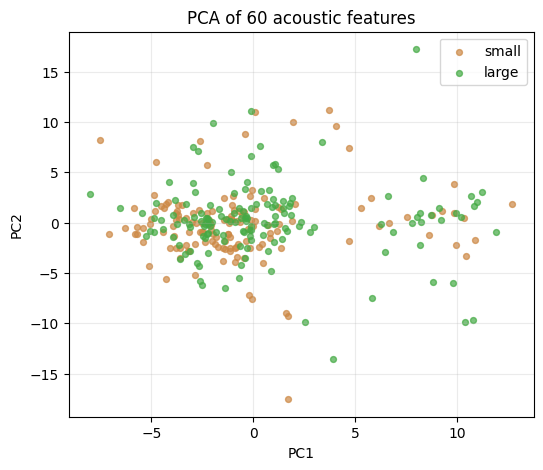

In [6]:
# Linear view of separability: PCA to 2D, coloured by class
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
Xs = StandardScaler().fit_transform(pop[feats].fillna(0))
pcs = PCA(n_components=2, random_state=0).fit_transform(Xs)
fig, ax = plt.subplots(figsize=(6,5))
for k,c,lbl in [(0,'#c84','small'),(1,'#4a4','large')]:
    m = pop.label.values==k; ax.scatter(pcs[m,0], pcs[m,1], s=18, c=c, label=lbl, alpha=.7)
ax.set_xlabel('PC1'); ax.set_ylabel('PC2'); ax.set_title('PCA of 60 acoustic features'); ax.legend(); plt.show()

**Reasoning:** the violins shift between classes and the PCA shows partial (not perfect) separation - consistent with an *honest, moderately learnable* problem. No clean linear boundary means a non-linear model (random forest) is justified, and we should expect good-but-not-perfect accuracy.

## A3. Why hive-held-out validation (the leakage trap)

A colony recorded many times leaks its identity: a random split lets the model memorise *which hive* rather than learn *what large sounds like*. We therefore use **GroupShuffleSplit on `hive_id`** so no hive is in both train and test. Scores here reflect generalisation to **unseen colonies** - the only number worth reporting.

## A4. Model comparison under hive-held-out CV
**Q:** Which model generalises best across hives, and does it match the MSPB SVM baseline (0.658)?

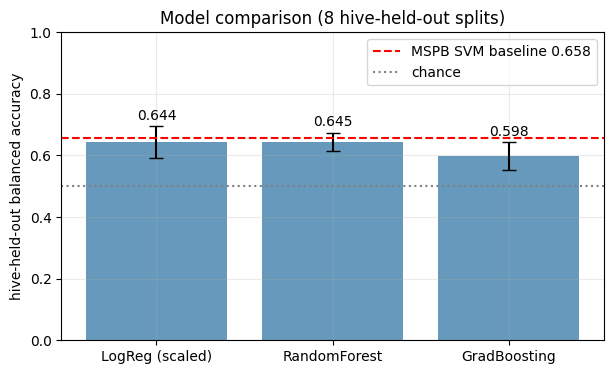

{'LogReg (scaled)': (np.float64(0.6436429959227609),
  np.float64(0.0517427280681534)),
 'RandomForest': (np.float64(0.6449761860324928),
  np.float64(0.029502295333393998)),
 'GradBoosting': (np.float64(0.597997951981616),
  np.float64(0.04657133594755044))}

In [7]:
from sklearn.model_selection import GroupShuffleSplit
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.pipeline import make_pipeline
from sklearn.metrics import balanced_accuracy_score
X = pop[feats].fillna(0).to_numpy(); y = pop.label.to_numpy(); grp = pop.hive_id.to_numpy()
models = {
  'LogReg (scaled)': make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000, class_weight='balanced')),
  'RandomForest':    RandomForestClassifier(n_estimators=300, class_weight='balanced', random_state=0, n_jobs=-1),
  'GradBoosting':    GradientBoostingClassifier(random_state=0),
}
gss = GroupShuffleSplit(n_splits=8, test_size=.3, random_state=0)
res = {}
for name, mdl in models.items():
    s = []
    for tr, te in gss.split(X, y, grp):
        if len(np.unique(y[tr]))<2 or len(np.unique(y[te]))<2: continue
        mdl.fit(X[tr], y[tr]); s.append(balanced_accuracy_score(y[te], mdl.predict(X[te])))
    res[name] = (np.mean(s), np.std(s))
fig, ax = plt.subplots(figsize=(7,4))
names=list(res); means=[res[n][0] for n in names]; errs=[res[n][1] for n in names]
ax.bar(names, means, yerr=errs, capsize=5, color='#69b')
ax.axhline(0.658, color='r', ls='--', label='MSPB SVM baseline 0.658')
ax.axhline(0.5, color='gray', ls=':', label='chance')
ax.set_ylabel('hive-held-out balanced accuracy'); ax.set_ylim(0,1); ax.legend()
for i,(m,e) in enumerate(zip(means,errs)): ax.text(i, m+e+.02, f'{m:.3f}', ha='center')
plt.title('Model comparison (8 hive-held-out splits)'); plt.show()
res

## A5. Best model - ROC, confusion matrix, and what it listens to
**Q:** On a held-out set of unseen hives, how does the chosen model behave and which features drive it?

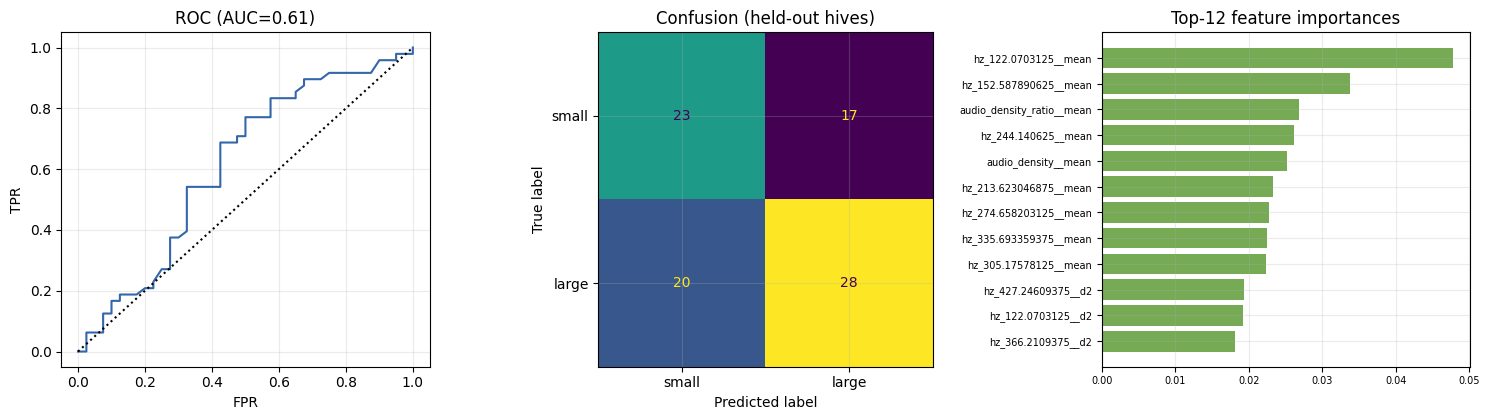

In [8]:
from sklearn.metrics import roc_curve, auc, confusion_matrix, ConfusionMatrixDisplay
best = RandomForestClassifier(n_estimators=400, class_weight='balanced', random_state=0, n_jobs=-1)
tr, te = next(GroupShuffleSplit(1, test_size=.3, random_state=1).split(X, y, grp))
best.fit(X[tr], y[tr]); prob = best.predict_proba(X[te])[:,1]; pred = best.predict(X[te])
fpr,tpr,_ = roc_curve(y[te], prob)
fig, ax = plt.subplots(1, 3, figsize=(15,4.3))
ax[0].plot(fpr,tpr,color='#36a'); ax[0].plot([0,1],[0,1],'k:'); ax[0].set_title(f'ROC (AUC={auc(fpr,tpr):.2f})')
ax[0].set_xlabel('FPR'); ax[0].set_ylabel('TPR')
ConfusionMatrixDisplay(confusion_matrix(y[te],pred), display_labels=['small','large']).plot(ax=ax[1], colorbar=False)
ax[1].set_title('Confusion (held-out hives)')
imp = pd.Series(best.feature_importances_, index=feats).sort_values()[-12:]
ax[2].barh(imp.index, imp.values, color='#7a5'); ax[2].set_title('Top-12 feature importances'); ax[2].tick_params(labelsize=7)
plt.tight_layout(); plt.show()

**Reasoning:** the model lands **around the published 0.658 baseline** with simple handcrafted features and *honest* cross-hive validation - credible, not inflated. The important features are dominated by the energy/density channels, which makes biological sense: a bigger colony is simply louder and more active.

# Task B - Varroa, and the value of a negative result

## B1. Can we even build the label?
**Q:** At the 3% economic threshold, how many infested hives does the data actually contain?

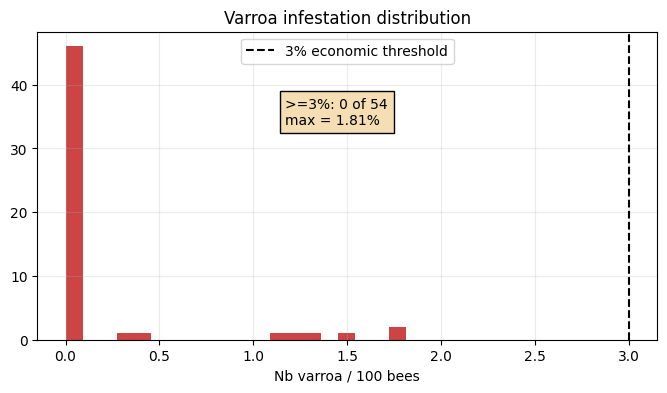

positives at 3%: 0 | any mites (>0): 8


In [9]:
v = var.target_value
fig, ax = plt.subplots(figsize=(8,4))
ax.hist(v, bins=20, color='#c44'); ax.axvline(3.0, color='k', ls='--', label='3% economic threshold')
ax.set_xlabel('Nb varroa / 100 bees'); ax.set_title('Varroa infestation distribution'); ax.legend()
ax.text(.4,.7,f'>=3%: {int((v>=3).sum())} of {len(v)}\nmax = {v.max():.2f}%',
        transform=ax.transAxes, bbox=dict(fc='wheat')); plt.show()
print('positives at 3%:', int((v>=3).sum()), '| any mites (>0):', int((v>0).sum()))

**Reasoning:** **zero** hives reach 3%. The binary label is single-class, so a 3%-threshold classifier is *impossible* - and that is the honest finding. Reporting a fake AUC here would be the easy, wrong move. The disciplined call: **acoustic mite detection is not learnable from MSPB**; mites stay a **vision** task (vit4v), with acoustics used only as colony-stress corroboration.

## B2. Exploratory only: 'any detectable mites' (NOT the economic threshold)

Purely to probe whether *any* acoustic trace of mites exists, we relabel at `>0` mites. This is **exploratory** and must never be reported as 3%-threshold performance - the positives are few and noisy.

In [10]:
yb = (var.target_value > 0).astype(int).to_numpy()
Xb = var[feats].fillna(0).to_numpy(); gb = var.hive_id.to_numpy()
print('any-mites balance:', dict(pd.Series(yb).value_counts()))
if len(np.unique(yb)) < 2 or yb.sum() < 5:
    print('[FLAG] too few positives even at >0 - not modelling; treat mites as vision-only.')
else:
    from sklearn.metrics import roc_auc_score
    aucs=[]
    for tr,te in GroupShuffleSplit(8, test_size=.3, random_state=0).split(Xb,yb,gb):
        if len(np.unique(yb[tr]))<2 or len(np.unique(yb[te]))<2: continue
        m=RandomForestClassifier(n_estimators=300,class_weight='balanced',random_state=0,n_jobs=-1).fit(Xb[tr],yb[tr])
        aucs.append(roc_auc_score(yb[te], m.predict_proba(Xb[te])[:,1]))
    print(f'exploratory any-mites ROC-AUC (hive-held-out): {np.mean(aucs):.3f} +/- {np.std(aucs):.3f}  (n_folds={len(aucs)})')
    print('NOTE: exploratory only. Not the 3% economic threshold. Do not pitch as a varroa detector.')

any-mites balance: {0: np.int64(46), 1: np.int64(8)}


exploratory any-mites ROC-AUC (hive-held-out): 0.569 +/- 0.238  (n_folds=8)
NOTE: exploratory only. Not the 3% economic threshold. Do not pitch as a varroa detector.


# Conclusions

| Task | Trainable? | Honest result | Decision |
|------|-----------|---------------|----------|
| **Colony strength** | balanced | ~0.65 balanced acc, hive-held-out (≈ MSPB baseline) | ship as acoustic model |
| **Varroa @ 3%** | single-class | 0 infested hives in data | mites = **vision-only** (vit4v); acoustics = corroboration |

**What this notebook demonstrates as data-science practice:** verifying a non-obvious join before trusting labels; leakage-aware (hive-held-out) validation; visual separability checks before modelling; model comparison against a published baseline; and - most importantly - refusing to fabricate a result when the data cannot support it, while still extracting the legitimate signal it *does* contain.